# 🏁 Train/Eval Leaderboard

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/train-eval-harness/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/train-eval-harness/demo.ipynb)

> Model selection is usually ad-hoc: train three classifiers in a notebook, eyeball one accuracy number, ship whichever looked best on one lucky split. This harness runs the **same stratified cross-validation** over a roster of models, scores every fold on several metrics, and ranks them with a **mean ± std leaderboard** - so the comparison is honest and reproducible.

**What this notebook covers**
1. A synthetic churn dataset with mixed column types
2. The model roster (including a majority-class baseline as a sanity floor)
3. Running the cross-validated leaderboard in one call
4. Reading the ranked results - mean *and* stability
5. Visualizing the per-fold spread (📊 boxplot)
6. Try your own dataset

## Step 1 - The problem

You have five candidate models. Which one do you ship? Comparing a single train/test accuracy is fragile: one split can flatter a model that is actually unstable. The fix is **k-fold cross-validation on identical folds**, scored on several metrics, with a **baseline** that any real model must beat.

We build a synthetic churn table (numeric + categorical columns, moderate signal) so everything runs with no downloads and no API keys.

In [1]:
from __future__ import annotations

from harness import (
    make_sample_data,
    default_models,
    run_leaderboard,
    format_leaderboard,
    DEFAULT_METRICS,
)

df = make_sample_data()
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
print("churn rate:", round(df['churned'].mean(), 3))
df.head()

900 rows x 6 columns
churn rate: 0.698


,tenure_months,monthly_charges,support_tickets,plan,contract,churned
0,7,81.87,0,basic,yearly,1
1,55,66.72,4,basic,monthly,1
2,47,24.23,3,basic,monthly,1
3,32,93.21,1,pro,monthly,1
4,31,54.87,3,pro,monthly,0


## Step 2 - The roster

Five estimators of increasing complexity. The **`Baseline (majority)`** always predicts the most common class - if a fancy model can't beat it, that model is worthless. Every estimator is wrapped in the same impute → scale → one-hot preprocessing pipeline *inside* the CV loop, so fold statistics never leak across splits.

In [2]:
for name, est in default_models().items():
    print(f"- {name:22s} -> {type(est).__name__}")

- Baseline (majority)    -> DummyClassifier
- Logistic Regression    -> LogisticRegression
- Decision Tree          -> DecisionTreeClassifier
- Random Forest          -> RandomForestClassifier
- Gradient Boosting      -> GradientBoostingClassifier


## Step 3 - Run the leaderboard

One call. It builds a leakage-safe pipeline per model, runs stratified 5-fold CV, scores Accuracy / ROC AUC / F1 / Precision / Recall on each fold, and returns a ranked table plus tidy per-fold detail for plotting.

In [3]:
leaderboard, folds = run_leaderboard(df, target="churned", n_splits=5)
format_leaderboard(leaderboard)

,rank,model,Accuracy,ROC AUC,F1,Precision,Recall,fit time (s)
0,1,Logistic Regression,0.752 ± 0.023,0.787 ± 0.039,0.835 ± 0.014,0.781 ± 0.018,0.897 ± 0.015,0.009
1,2,Decision Tree,0.730 ± 0.027,0.732 ± 0.027,0.812 ± 0.021,0.788 ± 0.014,0.839 ± 0.034,0.007
2,3,Random Forest,0.726 ± 0.020,0.734 ± 0.051,0.817 ± 0.014,0.764 ± 0.012,0.877 ± 0.024,0.191
3,4,Gradient Boosting,0.722 ± 0.024,0.748 ± 0.040,0.812 ± 0.019,0.769 ± 0.014,0.861 ± 0.040,0.068
4,5,Baseline (majority),0.698 ± 0.003,0.500 ± 0.000,0.822 ± 0.002,0.698 ± 0.003,1.000 ± 0.000,0.017


## Step 4 - Read it honestly

Two things matter, not one:

- **Mean** - the headline score. We rank by the first metric (Accuracy), but ROC AUC is often the better tie-breaker on imbalanced churn.
- **± std** - stability across folds. A high mean with a wide spread is *riskier* than a slightly lower but tight score.

Notice the baseline sits at **ROC AUC ≈ 0.500** (a coin flip) - exactly what a no-skill classifier should score. Every real model clears it, which is the minimum bar for shipping anything.

In [4]:
top = leaderboard.iloc[0]
print(f"Winner: {top['model']}")
print(f"  Accuracy : {top['Accuracy mean']:.3f} +/- {top['Accuracy std']:.3f}")
print(f"  ROC AUC  : {top['ROC AUC mean']:.3f} +/- {top['ROC AUC std']:.3f}")

baseline = leaderboard[leaderboard['model'] == 'Baseline (majority)'].iloc[0]
lift = top['ROC AUC mean'] - baseline['ROC AUC mean']
print(f"\nROC AUC lift over majority baseline: +{lift:.3f}")

Winner: Logistic Regression
  Accuracy : 0.752 +/- 0.023
  ROC AUC  : 0.787 +/- 0.039

ROC AUC lift over majority baseline: +0.287


## Step 5 - Visualize the per-fold spread 📊

The leaderboard collapses each model to mean ± std. A boxplot shows the actual fold-to-fold distribution: the box is the interquartile range, the line is the median. **Wide boxes = unstable.** This is where you catch a model that "won on average" but swings wildly between folds.

/var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/ipykernel_70436/3196434463.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, tick_labels=order, patch_artist=True)


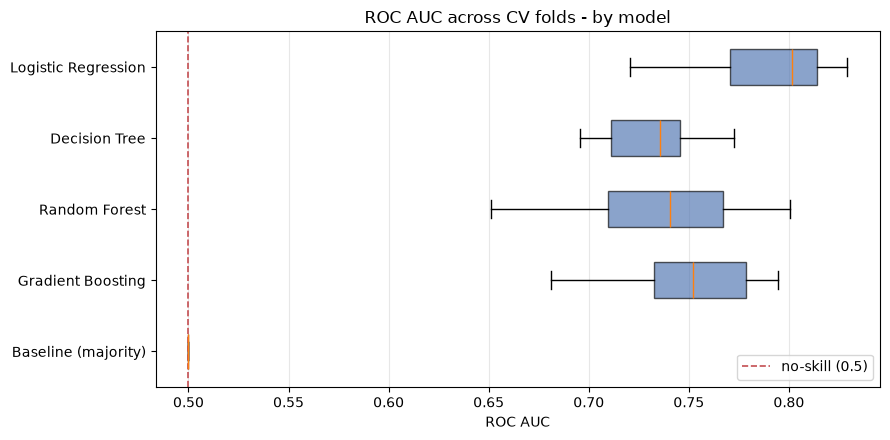

In [5]:
import matplotlib.pyplot as plt

metric = "ROC AUC"
order = leaderboard["model"].tolist()[::-1]  # best at top
data = [folds[(folds.model == m) & (folds.metric == metric)]["score"].values for m in order]

fig, ax = plt.subplots(figsize=(9, 4.5))
bp = ax.boxplot(data, vert=False, tick_labels=order, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.65)
ax.axvline(0.5, color="#C44E52", linestyle="--", linewidth=1.2, label="no-skill (0.5)")
ax.set_xlabel(metric)
ax.set_title(f"{metric} across CV folds - by model")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("leaderboard_spread.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

| Step | Result |
|------|--------|
| Dataset | ~900 rows, mixed numeric + categorical, ~30% churn |
| Method | stratified 5-fold CV, identical folds for every model, leakage-safe pipeline |
| Metrics | Accuracy, ROC AUC, F1, Precision, Recall - mean ± std |
| Guardrail | majority-class baseline pins the no-skill floor at AUC 0.5 |
| Output | ranked leaderboard + per-fold spread chart, both exportable |

Model choice is now a **ranked, reproducible decision** - not one lucky notebook split.

## Try your own dataset

Swap in any CSV with a binary target column. Everything else - preprocessing, CV, metrics, ranking - is automatic.

In [6]:
# import pandas as pd
# from harness import run_leaderboard, format_leaderboard
#
# my_df = pd.read_csv("your_data.csv")
# board, folds = run_leaderboard(my_df, target="your_binary_label", n_splits=5)
# format_leaderboard(board)
#
# # Add your own model to the roster:
# from sklearn.ensemble import ExtraTreesClassifier
# from harness import default_models
# roster = default_models()
# roster["Extra Trees"] = ExtraTreesClassifier(n_estimators=300, random_state=0)
# board, folds = run_leaderboard(my_df, target="your_binary_label", models=roster)

---
Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 72, ML Engineering Toolkit.

Prefer a UI? Run the Streamlit app to upload a CSV, pick the target, and download the leaderboard:
```bash
pip install -r requirements.txt
streamlit run app.py
```